In [2]:
import pandas as pd

df = pd.read_csv("../data/inverter_data.csv")

df.head()


,_id,mac,timestamp,inverters[0].pv1_power,inverters[1].pv1_power,inverters[2].pv1_power,inverters[3].pv1_power,inverters[4].pv1_power,inverters[5].pv1_power,inverters[6].pv1_power,...,smu[8].id,smu[9].id,smu[10].id,smu[11].id,createdAt,timestampDate,fromServer,dataLoggerModelId,__v,grid_master
0,65e1112670afbf1250c835db,ICR2-LT1-Celestical-10000.73,1709268300000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9,10,11,12,1709248806353,2024-03-01T04:45:00.000Z,raw_server_prod,6221cf1b102640607ef755d0,0,NaN
1,65e113f59047e3c478169edc,ICR2-LT1-Celestical-10000.73,1709268600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9,10,11,12,1709249525014,2024-03-01T04:50:00.000Z,raw_server_prod,6221cf1b102640607ef755d0,0,NaN
2,65e113f59047e3c478169ee9,ICR2-LT1-Celestical-10000.73,1709268900000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9,10,11,12,1709249525939,2024-03-01T04:55:00.000Z,raw_server_prod,6221cf1b102640607ef755d0,0,NaN
3,65e115d6dcd4ba087960bbfa,ICR2-LT1-Celestical-10000.73,1709269200000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9,10,11,12,1709250006223,2024-03-01T05:00:00.000Z,raw_server_prod,6221cf1b102640607ef755d0,0,NaN
4,65e115d7dcd4ba087960bc07,ICR2-LT1-Celestical-10000.73,1709269500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9,10,11,12,1709250007149,2024-03-01T05:05:00.000Z,raw_server_prod,6221cf1b102640607ef755d0,0,NaN


In [5]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189421 entries, 0 to 189420
Columns: 442 entries, _id to grid_master
dtypes: float64(409), int64(28), object(5)
memory usage: 638.8+ MB


In [10]:
df["timestampDate"] = pd.to_datetime(df["timestampDate"])

df = df.sort_values("timestampDate")

In [11]:
df = df.drop(columns=[
    "_id",
    "mac",
    "createdAt",
    "dataLoggerModelId",
    "__v"
], errors="ignore")


In [12]:
df = df.fillna(method="ffill")
df = df.fillna(0)b

/var/folders/pt/fm_7fmmx7bg47rfzxx5xc3_00000gn/T/ipykernel_52202/3628997502.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [13]:
df["pv1_power_mean"] = df["inverters[0].pv1_power"].rolling(10).mean()


In [14]:
df["pv1_power_std"] = df["inverters[0].pv1_power"].rolling(10).std()



In [16]:
df["pv1_power_lag1"] = df["inverters[0].pv1_power"].shift(1)
df["pv1_power_lag2"] = df["inverters[0].pv1_power"].shift(2)

In [17]:
df["failure"] = (df["inverters[0].pv1_power"] < 10).astype(int)

In [18]:
X = df.drop(["failure", "timestampDate"], axis=1)
y = df["failure"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from lightgbm import LGBMClassifier

model = LGBMClassifier()

model.fit(X_train, y_train)


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: fromServer: object

In [21]:
X_train.dtypes

timestamp                   int64
inverters[0].pv1_power    float64
inverters[1].pv1_power    float64
inverters[2].pv1_power    float64
inverters[3].pv1_power    float64
                           ...   
grid_master               float64
pv1_power_mean            float64
pv1_power_std             float64
pv1_power_lag1            float64
pv1_power_lag2            float64
Length: 440, dtype: object

In [22]:
X = df.drop(columns=["failure"])
y = df["failure"]

# keep only numeric columns
X = X.select_dtypes(include=["number"])


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [25]:
from lightgbm import LGBMClassifier

model = LGBMClassifier()

model.fit(X_train, y_train)b

[LightGBM] [Fatal] Do not support special JSON characters in feature name.


LightGBMError: Do not support special JSON characters in feature name.

In [27]:
# clean column names
df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


In [28]:
# clean column names
df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# create target
X = df.drop(columns=["failure"])
y = df["failure"]

# keep numeric columns
X = X.select_dtypes(include=["number"])

# fill missing values
X = X.fillna(0)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from lightgbm import LGBMClassifier

model = LGBMClassifier()

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 79301, number of negative: 72235
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 95971
[LightGBM] [Info] Number of data points in the train set: 151536, number of used features: 413
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.523315 -> initscore=0.093326
[LightGBM] [Info] Start training from score 0.093326
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier()

In [29]:
print(X.columns[:10])


Index(['timestamp', 'inverters_0_pv1_power', 'inverters_1_pv1_power',
       'inverters_2_pv1_power', 'inverters_3_pv1_power',
       'inverters_4_pv1_power', 'inverters_5_pv1_power',
       'inverters_6_pv1_power', 'inverters_7_pv1_power',
       'inverters_8_pv1_power'],
      dtype='object')


In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")

print("F1 CV Score:", scores.mean())


[LightGBM] [Info] Number of positive: 63440, number of negative: 57788
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 95810
[LightGBM] [Info] Number of data points in the train set: 121228, number of used features: 413
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.523311 -> initscore=0.093313
[LightGBM] [Info] Start training from score 0.093313
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Precision: 0.9998483086413511
Recall: 0.9995955919522799
F1: 0.9997219343259435
AUC: 0.9999997179665469


In [33]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# use class 1 (failure)
shap.summary_plot(shap_values[1], X_test)

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


AssertionError: Summary plots need a matrix of shap_values, not a vector.

In [34]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# use class 1 (failure)
shap.summary_plot(shap_values[1], X_test)

/opt/anaconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


AssertionError: Summary plots need a matrix of shap_values, not a vector.

 98%|===================| 37187/37885 [00:48<00:00]        

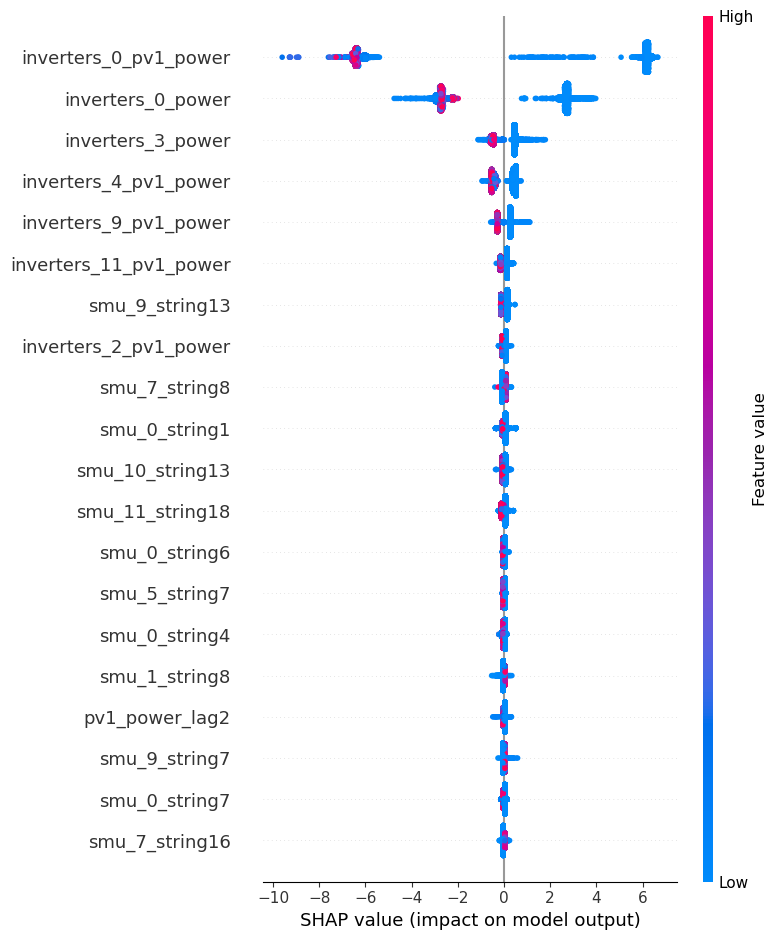

 99%|===================| 37464/37885 [00:48<00:00]        

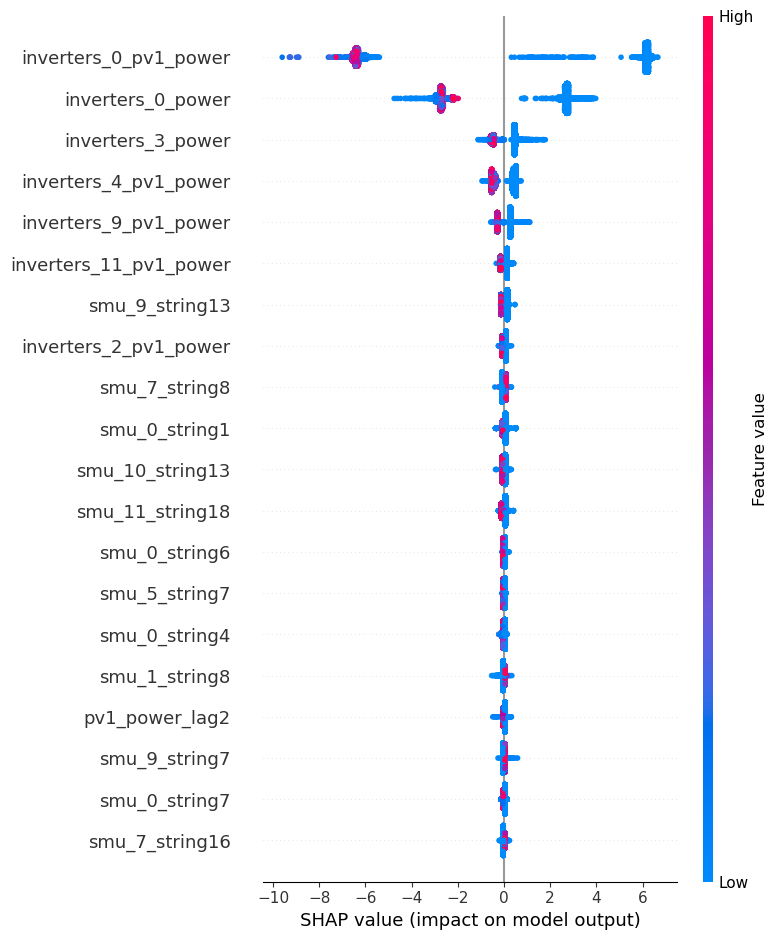

In [41]:
import shap

explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)